<a href="https://colab.research.google.com/github/mansillanatalia638-wq/studious-octo-pancake/blob/main/%E2%80%9C%E2%80%9C%E5%9F%BA%E5%85%83%E8%BD%AC%E5%8C%96%E7%AE%97%E6%B3%95_final_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khan1803115/hypertension-risk-model-main")

print("Path to dataset files:", path)

######################################################################
import pandas as pd
import numpy as np
import os

# List contents of the directory
directory_contents = os.listdir(path)
print(f"Contents of the directory '{path}': {directory_contents}")

# Assuming the CSV file is directly inside the downloaded directory and there's only one
csv_files = [f for f in directory_contents if f.endswith('.csv')]

if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    print(f"Attempting to read: {csv_file_path}")
    df = pd.read_csv(csv_file_path)
    df.head()
else:
    print("No CSV files found in the directory.")

df.head()

100%|██████████| 54.2k/54.2k [00:00<00:00, 40.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/khan1803115/hypertension-risk-model-main/versions/1


Contents of the directory '/root/.cache/kagglehub/datasets/khan1803115/hypertension-risk-model-main/versions/1': ['Hypertension-risk-model-main.csv']
Attempting to read: /root/.cache/kagglehub/datasets/khan1803115/hypertension-risk-model-main/versions/1/Hypertension-risk-model-main.csv


,male,age,currentSmoker,cigsPerDay,BPMeds,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Risk
0,1,39,0,0.0,0.0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
len(df)

4240

🧿Data Evaluation

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   male           4240 non-null   int64  
 1   age            4240 non-null   int64  
 2   currentSmoker  4240 non-null   int64  
 3   cigsPerDay     4211 non-null   float64
 4   BPMeds         4187 non-null   float64
 5   diabetes       4240 non-null   int64  
 6   totChol        4190 non-null   float64
 7   sysBP          4240 non-null   float64
 8   diaBP          4240 non-null   float64
 9   BMI            4221 non-null   float64
 10  heartRate      4239 non-null   float64
 11  glucose        3852 non-null   float64
 12  Risk           4240 non-null   int64  
dtypes: float64(8), int64(5)
memory usage: 430.8 KB


In [ ]:
df.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Risk
count,4240.000000,4240.000000,4240.000000,4211.000000,4187.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,0.494104,9.005937,0.029615,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.310613
std,0.495027,8.572942,0.500024,11.922462,0.169544,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.462799
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,1.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


🧹Data Cleaning & Preprocessing¶

In [ ]:
# checking for null values
df.isna().sum()

,0
male,0
age,0
currentSmoker,0
cigsPerDay,29
BPMeds,53
diabetes,0
totChol,50
sysBP,0
diaBP,0
BMI,19


In [ ]:
# dropping null values
df.dropna(inplace = True)
df.reset_index(drop=True, inplace=True)

In [ ]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

**🔥Heatmap¶**

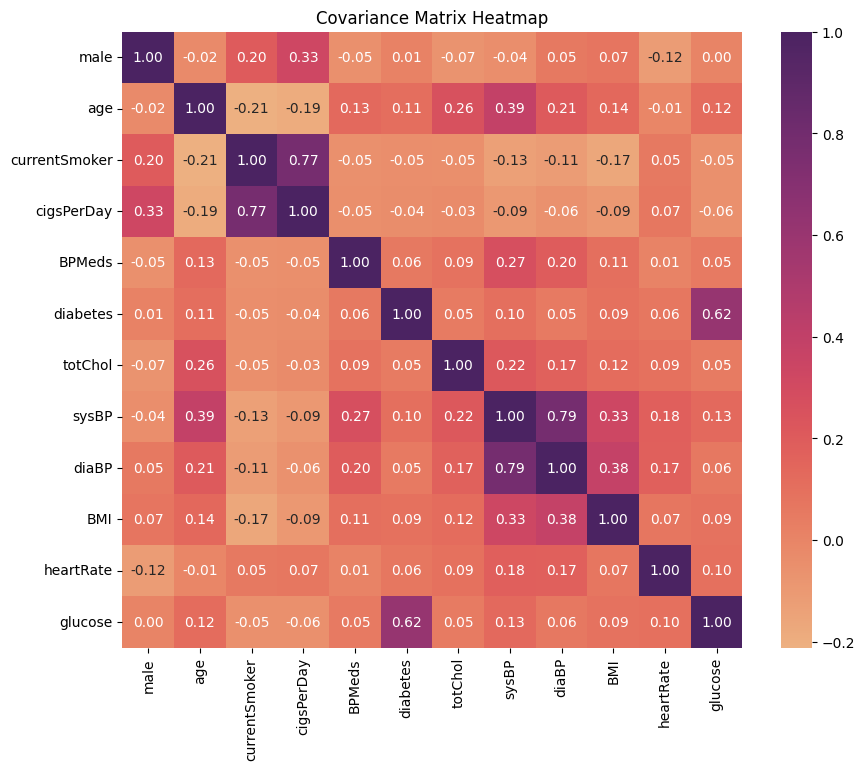

In [ ]:
# checking for redundant features with high correlation
import seaborn as sns
import matplotlib.pyplot as plt

# calculating the correlating matrix without the target variable
features = df.drop('Risk', axis = 1)
corr_matrix = features.corr()

# plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='flare', fmt='.2f')
plt.title('Covariance Matrix Heatmap')
plt.show()

We can see that there are a few features with very high correlation so we drop them.


In [ ]:
df = df.drop(['diabetes', 'currentSmoker'], axis=1)

In [ ]:
num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
cat_cols = ['male', 'BPMeds']

🎈Removing Outliers¶


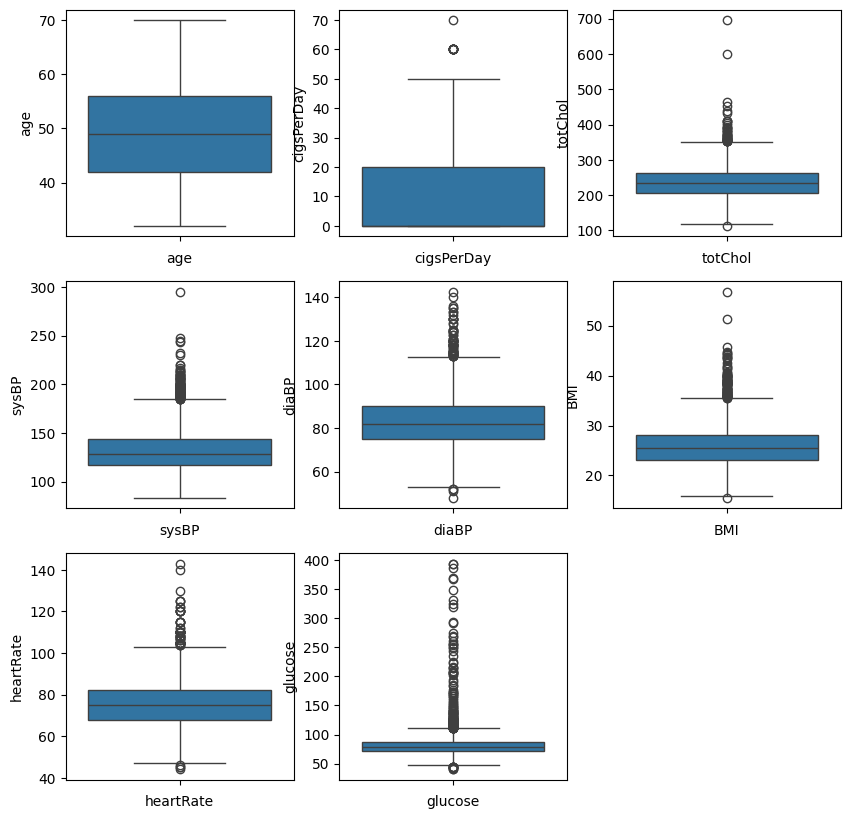

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# selecting columns to plot box plot
cols = df[num_cols]

# checking outliers
plt.figure(figsize=(10,10),facecolor='white')
plotnumber=1

for column in cols[1:]:
    ax=plt.subplot(3,3,plotnumber)
    sns.boxplot(df[column])
    plt.xlabel(column,fontsize=10)
    plotnumber+=1


In [ ]:
# function to remove outliers using the IQR method
def remove_outliers(df, columns):

    # looping through each column
    for col in columns:
        feature = df[col]
        q1 = feature.quantile(0.25)
        q3 = feature.quantile(0.75)
        IQR = q3 - q1
        lower_bound = float(q1 - 1.5 * IQR)  # Cast to float
        upper_bound = float(q3 + 1.5 * IQR)  # Cast to float

        # replacing outliers with bounds
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    return df

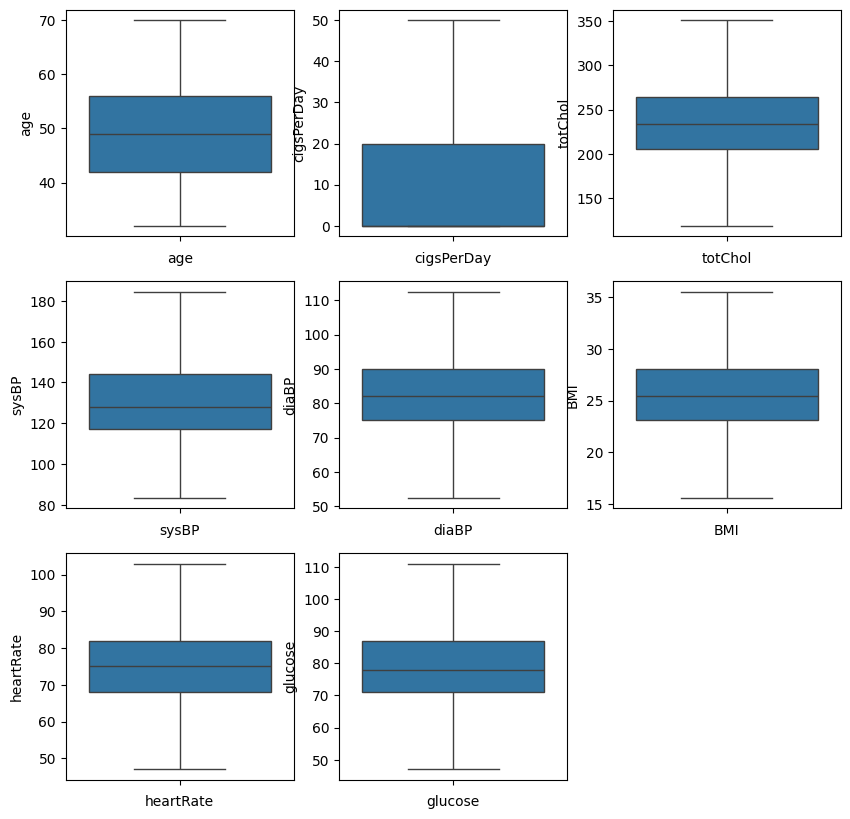

In [ ]:
# Remove outliers from specified columns
df = remove_outliers(df, cols)

# checking outliers
plt.figure(figsize=(10,10),facecolor='white')
plotnumber=1

for column in cols[1:]:
    ax=plt.subplot(3,3,plotnumber)
    sns.boxplot(df[column])
    plt.xlabel(column,fontsize=10)
    plotnumber+=1

🛩Distribution Plot¶


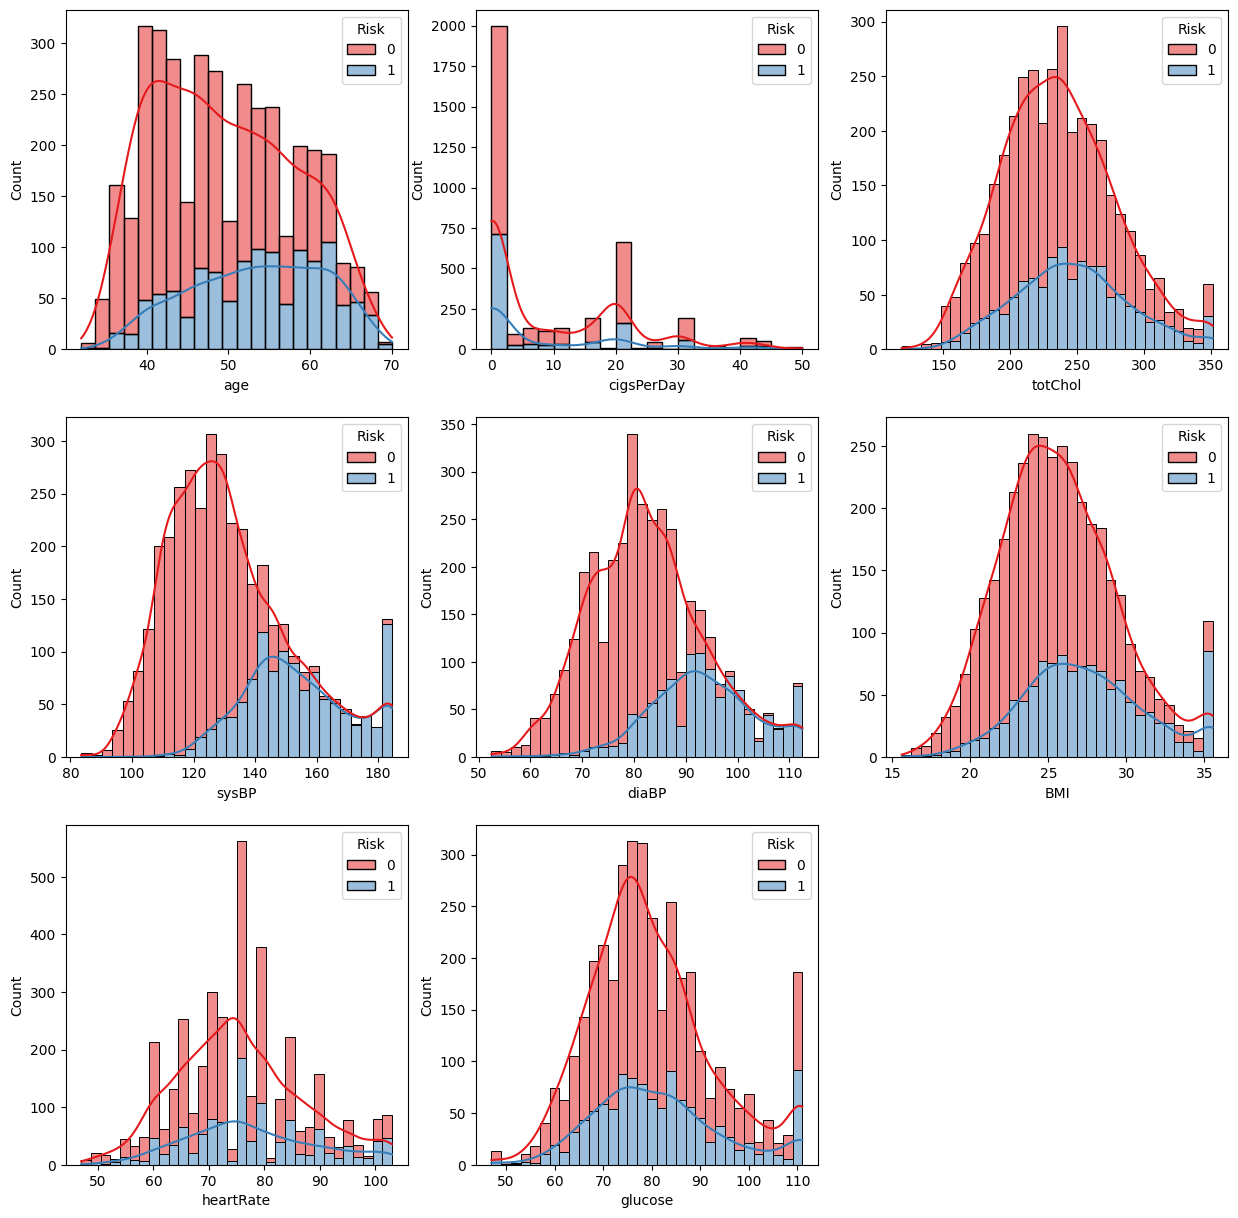

In [ ]:
# plotting distplot
plt.figure(figsize=(15,15),facecolor='white')
plotnumber=1

for column in cols[1:]:
    ax = plt.subplot(3, 3, plotnumber)
    sns.histplot(data=df, x=column, hue='Risk', kde=True, multiple='stack', palette='Set1')
    plt.xlabel(column, fontsize=10)
    plotnumber += 1


🎞Scaling Data¶


In [ ]:
# from sklearn.preprocessing import StandardScaler

# # Standard Scaling of numerical columns
# scaler = StandardScaler()
# df[num_cols] = scaler.fit_transform(df[num_cols])

# df.head()


*🎄Splitting* Data¶


In [ ]:
df['my_risk'] = 1 - df['Risk']
df.head()

,male,age,cigsPerDay,BPMeds,totChol,sysBP,diaBP,BMI,heartRate,glucose,Risk,my_risk
0,1,39.0,0.0,0.0,195.0,106.0,70.0,26.97,80.0,77.0,0,1
1,0,46.0,0.0,0.0,250.0,121.0,81.0,28.73,95.0,76.0,0,1
2,1,48.0,20.0,0.0,245.0,127.5,80.0,25.34,75.0,70.0,0,1
3,0,61.0,30.0,0.0,225.0,150.0,95.0,28.58,65.0,103.0,1,0
4,0,46.0,23.0,0.0,285.0,130.0,84.0,23.10,85.0,85.0,0,1


In [ ]:
# splitting data
X = df.drop(['Risk', 'my_risk'], axis = 1)
y = df['Risk']

# X = df.drop(['Risk', 'my_risk', 'sysBP', 'diaBP'], axis = 1)
# y = df['my_risk']

⚾Oversampling¶

In [ ]:
# checking for imbalanced dataset
y.value_counts()

,count
Risk,
0,2581
1,1170


In [ ]:
# oversampling
from imblearn.over_sampling import RandomOverSampler
oversampler = RandomOverSampler(random_state = 42)
X, y = oversampler.fit_resample(X,y)

y.value_counts()

,count
Risk,
0,2581
1,2581


🗻Train Test Split¶


In [ ]:
# splitting data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [ ]:
y_train.value_counts()

,count
Risk,
0,2073
1,2056


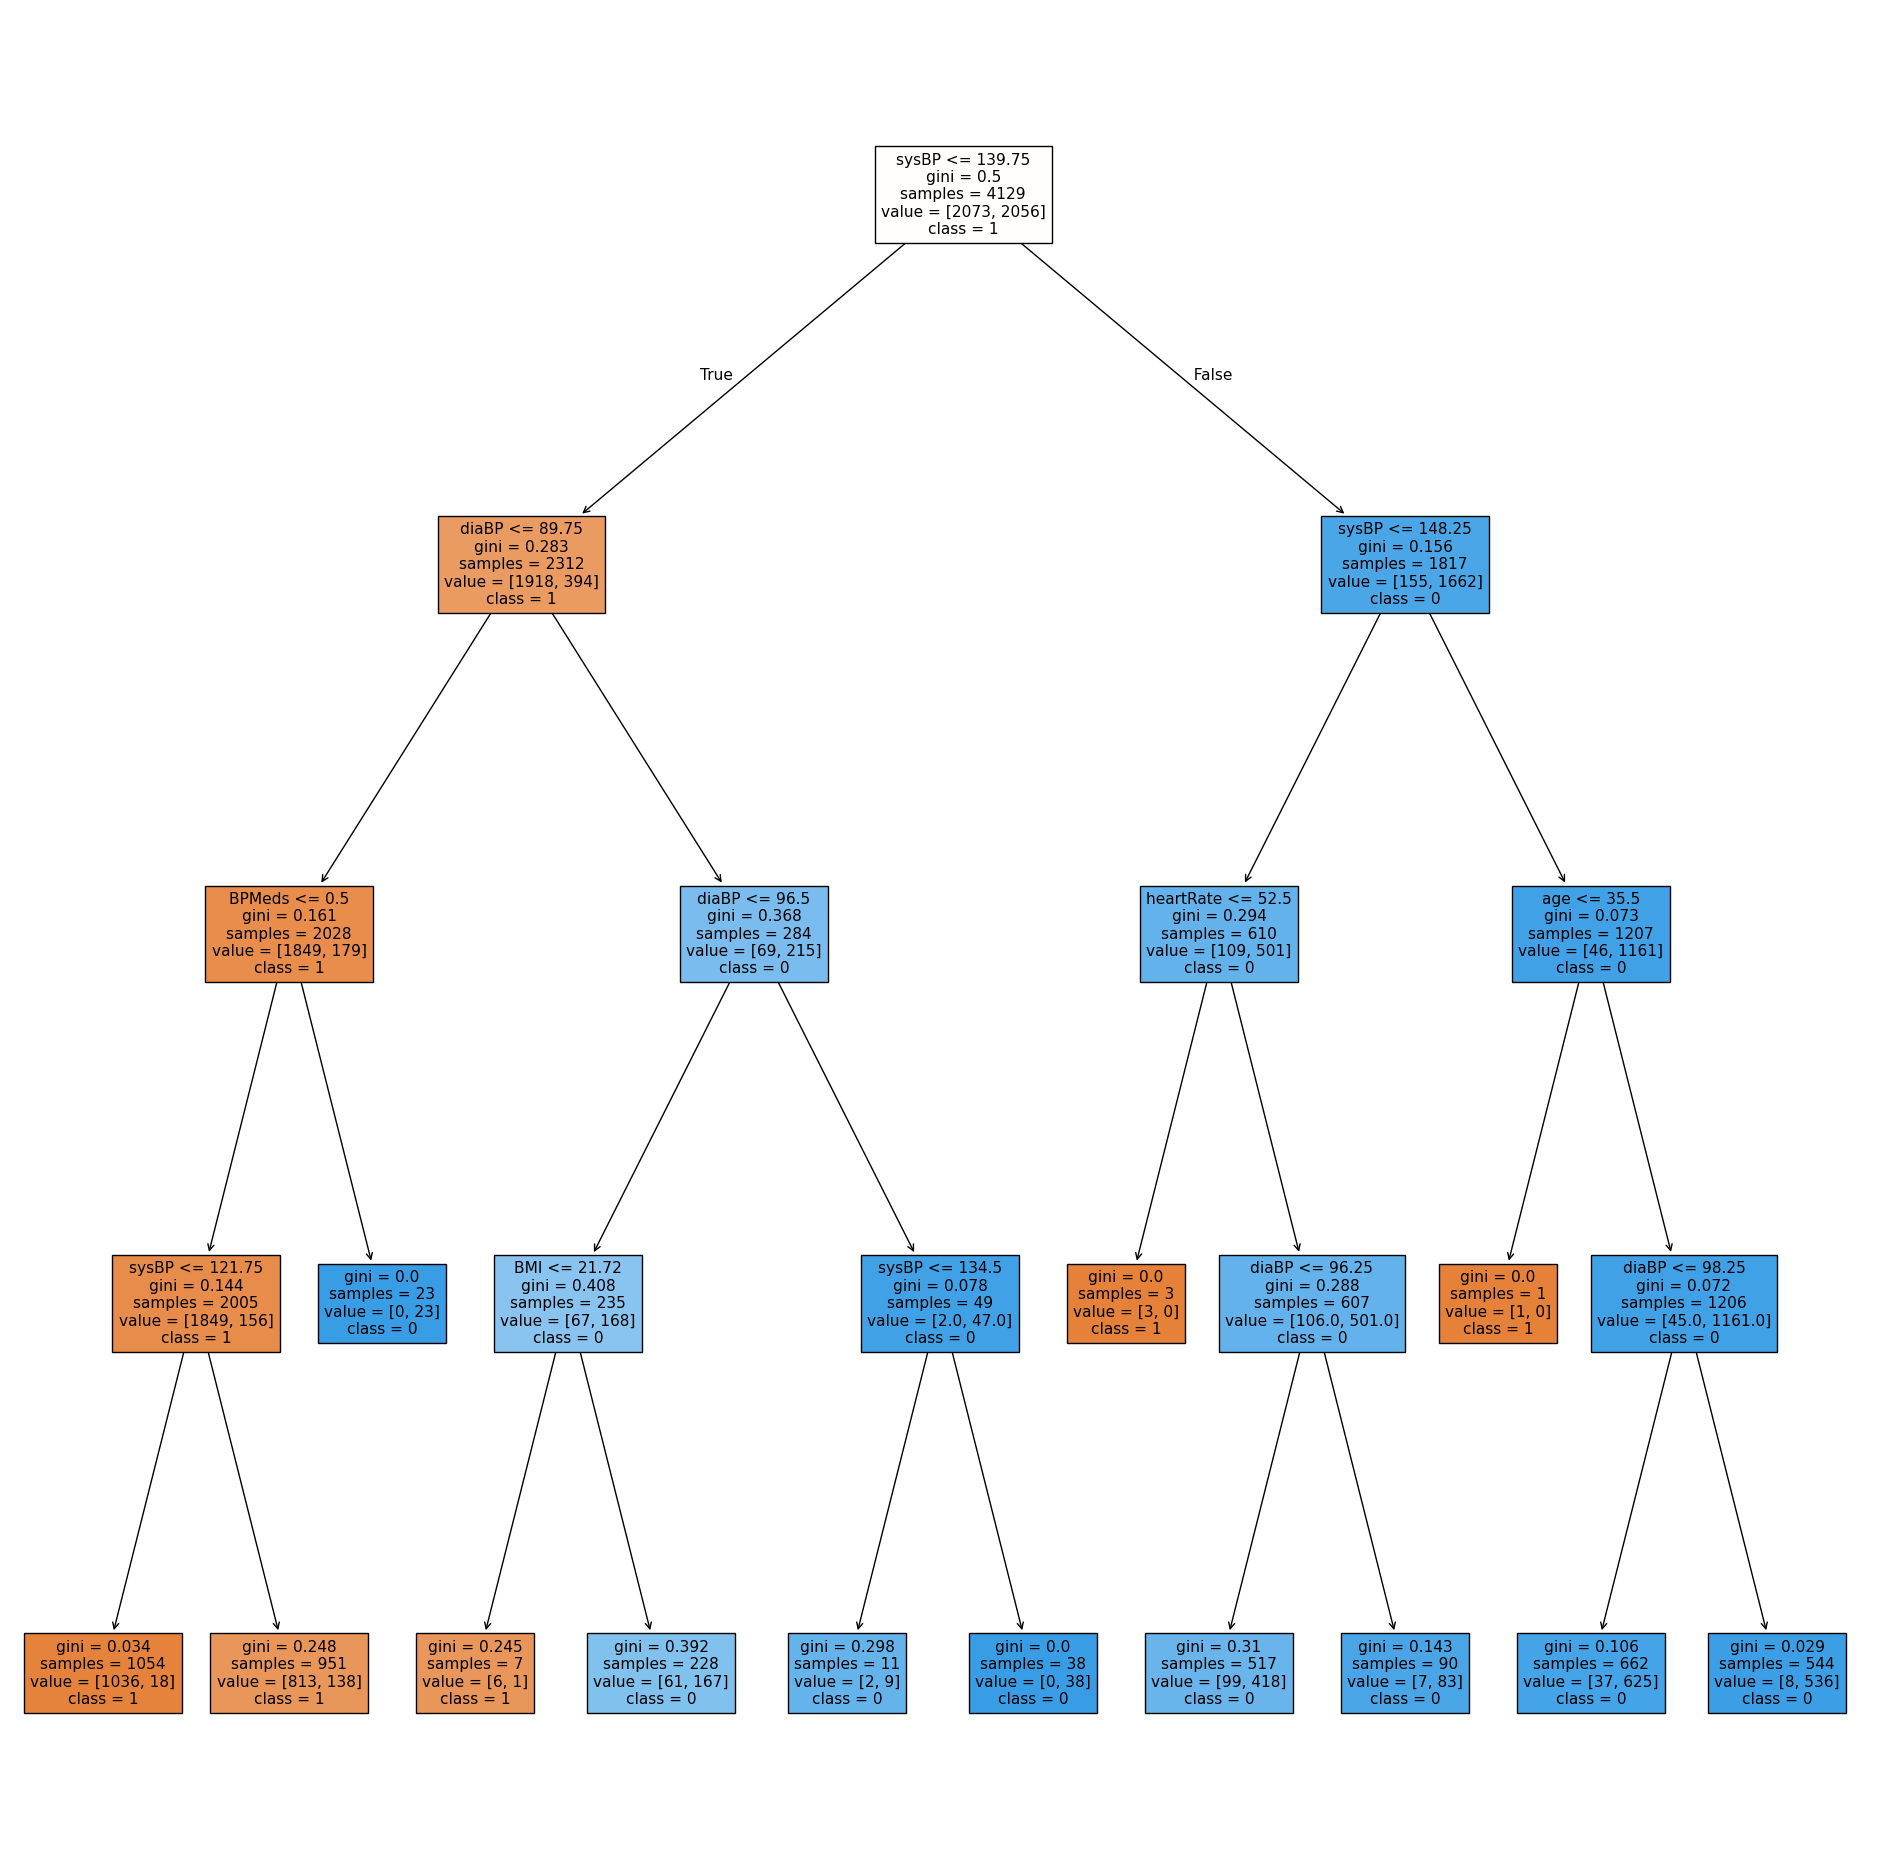

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(max_depth=4)
clf.fit(X_train, y_train)

# Define feature_names and class_labels
feature_names = X_train.columns.tolist()
class_labels = [str(label) for label in y_train.unique()]

plt.figure(figsize=(24,24))
plot_tree(clf, feature_names=feature_names, class_names=class_labels, filled=True)

plt.show()

Area under the precision-recall curve  0.9070097487814022


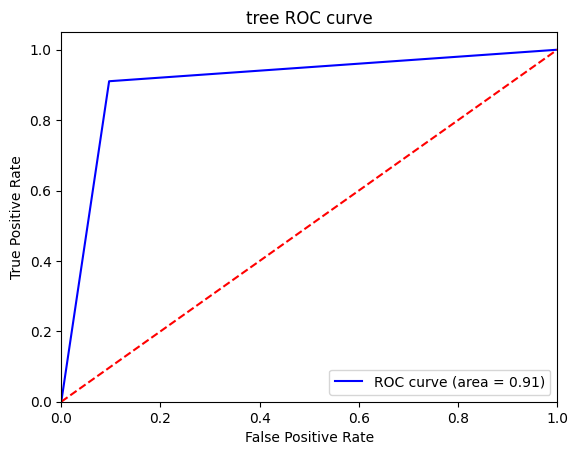

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       508
           1       0.91      0.91      0.91       525

    accuracy                           0.91      1033
   macro avg       0.91      0.91      0.91      1033
weighted avg       0.91      0.91      0.91      1033



In [ ]:

workspace = './'

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score as ras

def accuracy(model, test_val, preds):
    print("Area under the precision-recall curve ", ras(test_val.values, preds))
    fpr, tpr, _ = roc_curve(test_val.values, preds)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, 'b', label = 'ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(model + ' ROC curve')
    plt.legend(loc="lower right")
    plt.savefig(workspace + '/' + model + '-roc.png')
    plt.show()

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
preds = clf.predict(X_test)
accuracy('tree', y_test, preds)
print(classification_report( y_test, preds))

In [ ]:
def find_class_0_leaf_nodes(tree, node_id, identified_nodes):

    counts = tree.value[node_id][0]
    dominant_class = 0 if counts[0] >= counts[1] else 1

    is_leaf = (tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1)

    if is_leaf:
        if dominant_class == 0:
            identified_nodes.add(node_id)
        return

    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    find_class_0_leaf_nodes(tree, left_child, identified_nodes)
    find_class_0_leaf_nodes(tree, right_child, identified_nodes)


    if dominant_class == 0:
        left_child_counts = tree.value[left_child][0]
        right_child_counts = tree.value[right_child][0]

        left_child_dominant_class = 0 if left_child_counts[0] >= left_child_counts[1] else 1
        right_child_dominant_class = 0 if right_child_counts[0] >= right_child_counts[1] else 1

        if left_child_dominant_class == 0 and right_child_dominant_class == 0:

            if left_child in identified_nodes:
                identified_nodes.remove(left_child)
            if right_child in identified_nodes:
                identified_nodes.remove(right_child)
            identified_nodes.add(node_id)
identified_nodes = set()

find_class_0_leaf_nodes(clf.tree_, 0, identified_nodes)

special_leaf_node_ids = sorted(list(identified_nodes))

print(f"Identified special class 0 leaf nodes (IDs): {special_leaf_node_ids}")
print(f"Total number of special class 0 leaf nodes: {len(special_leaf_node_ids)}")

Identified special class 0 leaf nodes (IDs): [np.int64(3), np.int64(9), np.int64(16), np.int64(21)]
Total number of special class 0 leaf nodes: 4


In [ ]:
import pandas as pd
import numpy as np

def get_leaf_node_feature_ranges(tree, feature_names, special_leaf_node_ids):

    all_leaf_ranges_data = []

    def _traverse_and_collect_ranges(node_id, current_path_constraints):

        nonlocal all_leaf_ranges_data

        if node_id in special_leaf_node_ids:
            row_data = {'node_id': node_id}
            for feature_name in feature_names:
                if feature_name in current_path_constraints:
                    min_val, max_val = current_path_constraints[feature_name]

                    min_repr = X_train[feature_name].min() if min_val == -np.inf else min_val

                    max_repr = X_train[feature_name].max() if max_val == np.inf else max_val

                    row_data[feature_name] = (min_repr, max_repr)
                else:

                    row_data[feature_name] = 'NaN'
            all_leaf_ranges_data.append(row_data)

        if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
            return

        feature_idx = tree.feature[node_id]
        threshold = tree.threshold[node_id]
        feature_name = feature_names[feature_idx]

        current_min, current_max = current_path_constraints.get(feature_name, (-np.inf, np.inf))

        left_constraints = current_path_constraints.copy()

        left_constraints[feature_name] = (current_min, min(current_max, threshold))
        _traverse_and_collect_ranges(tree.children_left[node_id], left_constraints)

        right_constraints = current_path_constraints.copy()

        right_constraints[feature_name] = (max(current_min, threshold), current_max)
        _traverse_and_collect_ranges(tree.children_right[node_id], right_constraints)

    _traverse_and_collect_ranges(0, {})

    df_ranges = pd.DataFrame(all_leaf_ranges_data)

    if not df_ranges.empty:
        cols = ['node_id'] + sorted([col for col in df_ranges.columns if col != 'node_id'])
        df_ranges = df_ranges[cols]

    return df_ranges
df_special_leaf_ranges = get_leaf_node_feature_ranges(clf.tree_, feature_names, special_leaf_node_ids)

df_transposed = df_special_leaf_ranges.set_index('node_id').T
node_id_to_new_name = {node_id: f'叶节点{i+1}' for i, node_id in enumerate(df_transposed.columns)}

df_transposed = df_transposed.rename(columns=node_id_to_new_name)

# Explicitly sort columns by their numerical suffix to ensure order
df_transposed = df_transposed.reindex(sorted(df_transposed.columns, key=lambda x: int(x.replace('叶节点', ''))), axis=1)

# Reorder rows (features) based on the order in feature_names
df_transposed = df_transposed.reindex(feature_names)

for col in df_transposed.columns:
    for idx, val in df_transposed[col].items():
        if isinstance(val, tuple):
            min_val, max_val = val
            formatted_min = f'{min_val:.2f}' if isinstance(min_val, (int, float)) else min_val
            formatted_max = f'{max_val:.2f}' if isinstance(max_val, (int, float)) else max_val
            df_transposed.at[idx, col] = (formatted_min, formatted_max)

print("Features as Rows, Leaf Nodes as Columns:")
display(df_transposed)

Features as Rows, Leaf Nodes as Columns:


node_id,叶节点1,叶节点2,叶节点3,叶节点4
male,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,"(32.00, 35.50)"
cigsPerDay,NaN,NaN,NaN,NaN
BPMeds,"(0.00, 0.50)",NaN,NaN,NaN
totChol,NaN,NaN,NaN,NaN
sysBP,"(83.50, 139.75)","(83.50, 139.75)","(139.75, 148.25)","(148.25, 184.50)"
diaBP,"(52.50, 89.75)","(89.75, 96.50)",NaN,NaN
BMI,NaN,"(15.62, 21.72)",NaN,NaN
heartRate,NaN,NaN,"(47.00, 52.50)",NaN
glucose,NaN,NaN,NaN,NaN


In [ ]:
feature_values = [0, 50, 0, 0, 230, 126, 93, 25.36, 80, 84]

feature_dict = dict(zip(feature_names, feature_values[:len(feature_names)]))

print("创建的特征量值字典：")
print(feature_dict)

创建的特征量值字典：
{'male': 0, 'age': 50, 'cigsPerDay': 0, 'BPMeds': 0, 'totChol': 230, 'sysBP': 126, 'diaBP': 93, 'BMI': 25.36, 'heartRate': 80, 'glucose': 84}


In [ ]:
import math

results = {}

# Iterate through each feature in the feature_dict
for feature_name, feature_value in feature_dict.items():
    feature_results = []
    # Iterate through each leaf node column in df_transposed
    for leaf_node_col in df_transposed.columns:
        range_val = df_transposed.loc[feature_name, leaf_node_col]

        if range_val == 'NaN' or pd.isna(range_val): # Check for both string 'NaN' and pandas NaN
            feature_results.append('NaN')
        else:
            # Ensure min_val and max_val are floats for comparison
            min_val = float(range_val[0])
            max_val = float(range_val[1])

            if min_val <= feature_value <= max_val:
                feature_results.append(0.0)
            elif feature_value < min_val:
                feature_results.append(min_val - feature_value)
            else: # feature_value > max_val
                feature_results.append(feature_value - max_val)
    results[feature_name] = feature_results

# Create a DataFrame from the results
df_comparison = pd.DataFrame(results, index=df_transposed.columns).T

print("特征值与叶节点范围的比较结果：")
display(df_comparison)

特征值与叶节点范围的比较结果：


node_id,叶节点1,叶节点2,叶节点3,叶节点4
male,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,14.5
cigsPerDay,NaN,NaN,NaN,NaN
BPMeds,0.0,NaN,NaN,NaN
totChol,NaN,NaN,NaN,NaN
sysBP,0.0,0.0,13.75,22.25
diaBP,3.25,0.0,NaN,NaN
BMI,NaN,3.64,NaN,NaN
heartRate,NaN,NaN,27.5,NaN
glucose,NaN,NaN,NaN,NaN


In [ ]:
a= np.array([1, 0, 10, 5, 6, 6, 7, 8, 9, 5]) #难度系数
b=1 #成本系数
c=0 #固定成本
T = 0.5 #阈值

In [ ]:
import math
import numpy as np

def convert_difficulty(distance, a):
    if a == 0:
        return 0.0
    else:
        return math.exp(-distance / a)

def convert_cost(distance, b, c):
    return b * distance + c

In [ ]:
import numpy as np

df_difficulty = pd.DataFrame(index=df_comparison.index, columns=df_comparison.columns)

# Map 'a' values to feature names
a_values_map = dict(zip(feature_names, a))

# Iterate through each feature (row) and leaf node (column) to calculate difficulty
for feature_name in df_comparison.index:
    for leaf_node_col in df_comparison.columns:
        distance = df_comparison.loc[feature_name, leaf_node_col]
        a_val = a_values_map.get(feature_name)

        if pd.isna(distance) or distance == 'NaN': # Check for both pandas NaN and string 'NaN'
            df_difficulty.loc[feature_name, leaf_node_col] = np.nan
        elif distance == 0: # If distance is 0, convertibility is 1.0 (no distance to overcome)
            df_difficulty.loc[feature_name, leaf_node_col] = 1.0
        else: # distance is not NaN and not zero
            # Ensure distance is a float for calculation
            distance_float = float(distance)
            # Call the convert_difficulty function. It handles a_val == 0 internally by returning 0.0.
            df_difficulty.loc[feature_name, leaf_node_col] = convert_difficulty(distance_float, a_val)

print("可转化度计算结果：")
display(df_difficulty)

可转化度计算结果：


node_id,叶节点1,叶节点2,叶节点3,叶节点4
male,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,0.0
cigsPerDay,NaN,NaN,NaN,NaN
BPMeds,1.0,NaN,NaN,NaN
totChol,NaN,NaN,NaN,NaN
sysBP,1.0,1.0,0.101098,0.024518
diaBP,0.628584,1.0,NaN,NaN
BMI,NaN,0.634448,NaN,NaN
heartRate,NaN,NaN,0.047097,NaN
glucose,NaN,NaN,NaN,NaN


In [ ]:
import numpy as np
import pandas as pd

total_costs_per_leaf_node = {}

# 遍历 df_difficulty 的每一列 (即每个叶节点)
for leaf_node_col in df_difficulty.columns:
    current_leaf_total_cost = 0.0
    found_valid_cost_source = False # 标记是否找到任何可用于计算成本的项

    # 遍历当前叶节点列中的每一个特征的可转化度值
    for feature_name in df_difficulty.index:
        difficulty_value = df_difficulty.loc[feature_name, leaf_node_col]

        # 第一步：检查可转化度是否大于阈值 T
        if pd.isna(difficulty_value) or difficulty_value <= T:
            continue # 如果可转化度是 NaN 或不大于 T，则跳过此项

        # 第二步：如果可转化度大于 T，则从 df_comparison 获取对应的距离值来计算成本
        distance = df_comparison.loc[feature_name, leaf_node_col]

        # 检查距离值是否有效
        if pd.isna(distance) or distance == 'NaN':
            continue # 如果距离是 NaN，也跳过此项

        distance_float = float(distance)

        # 使用公式二: convert_cost(distance, b, c)
        cost = convert_cost(distance_float, b, c)
        current_leaf_total_cost += cost
        found_valid_cost_source = True

    # 如果该列没有找到可用于计算成本的项，则总成本为 NaN
    if not found_valid_cost_source:
        total_costs_per_leaf_node[leaf_node_col] = np.nan
    else:
        total_costs_per_leaf_node[leaf_node_col] = current_leaf_total_cost

# 将总成本字典转换为 Pandas Series
df_total_costs = pd.Series(total_costs_per_leaf_node, name='Total Conversion Cost')

# 将 df_total_costs Series 转换为 DataFrame，作为新的一行
df_total_costs_df = pd.DataFrame([df_total_costs], index=['Total Conversion Cost'])

# 将总成本行添加到 df_difficulty 表的最后
df_combined = pd.concat([df_difficulty, df_total_costs_df])

print("可转化度与总转化成本合并表：")
display(df_combined)

可转化度与总转化成本合并表：


,叶节点1,叶节点2,叶节点3,叶节点4
male,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,0.0
cigsPerDay,NaN,NaN,NaN,NaN
BPMeds,1.0,NaN,NaN,NaN
totChol,NaN,NaN,NaN,NaN
sysBP,1.0,1.0,0.101098,0.024518
diaBP,0.628584,1.0,NaN,NaN
BMI,NaN,0.634448,NaN,NaN
heartRate,NaN,NaN,0.047097,NaN
glucose,NaN,NaN,NaN,NaN


In [ ]:
total_costs_row = df_combined.loc['Total Conversion Cost']

min_cost_profile_name = total_costs_row.idxmin()
min_total_cost = total_costs_row.min()

print(f"成本最小的是: '{min_cost_profile_name}'，成本为: {min_total_cost:.2f}\n")

min_profile_difficulties = df_combined[min_cost_profile_name].drop('Total Conversion Cost')

features_to_change = []
for feature_name in min_profile_difficulties.index:
    difficulty_value = min_profile_difficulties.loc[feature_name]

    # 筛选条件：可转化度值非 NaN 且大于 T 且小于 1
    if difficulty_value is not np.nan and difficulty_value > T and difficulty_value < 1:
        features_to_change.append(feature_name)

if features_to_change:
    print(f"在 '{min_cost_profile_name}' 中，可通过改变以下特征达到正常:")
    for feature in features_to_change:
        print(f"- {feature}")
else:
    print(f"在 '{min_cost_profile_name}' 中，没有可改变的特征来达到正常状态（或所有可改变特征的可转化度都为1）。")

成本最小的是: '叶节点1'，成本为: 3.25

在 '叶节点1' 中，可通过改变以下特征达到正常:
- diaBP
